In [1]:
# Deutsch algorithm (1-bit) - Qiskit example
from qiskit import QuantumCircuit,transpile,assemble
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

# Build oracle circuits for the 4 possible functions f:{0,1}->{0,1}
# Oracle must implement |x>|y> -> |x>|y XOR f(x)|

def oracle_constant_0(qc, x=0, y=1):
    # f(x)=0 -> do nothing
    pass

def oracle_constant_1(qc, x=0, y=1):
    # f(x)=1 -> flip the target y
    qc.x(y)

def oracle_identity(qc, x=0, y=1):
    # f(x)=x -> CNOT(control=x, target=y)
    qc.cx(x, y)

def oracle_not(qc, x=0, y=1):
    # f(x)=1-x -> y <- y XOR (1-x) = (y XOR 1) XOR x
    # implement as: CNOT then X on target
    qc.cx(x, y)
    qc.x(y)

# Deutsch circuit builder
def deutsch_circuit(oracle_builder):
    qc = QuantumCircuit(2, 1)
    # prepare |0>|1>
    qc.x(1)               # set second qubit to |1>
    qc.h(0)
    qc.h(1)
    # oracle (apply the provided oracle_builder on qc)
    oracle_builder(qc, x=0, y=1)
    # Hadamard on the input qubit
    qc.h(0)
    # measure input qubit
    qc.measure(0, 0)
    return qc

# Choose an oracle: try all four
oracles = {
    "constant_0": oracle_constant_0,
    "constant_1": oracle_constant_1,
    "identity"  : oracle_identity,   # balanced: f(0)=0,f(1)=1
    "not"       : oracle_not         # balanced: f(0)=1,f(1)=0
}

sim = Aer.get_backend('aer_simulator')

for name, builder in oracles.items():
    qc = deutsch_circuit(builder)
    # Transpile for the simulator
    tqc = transpile(qc, sim)
    # Run directly — no assemble(), no qobj
    result = sim.run(tqc, shots=1024).result()
    counts = result.get_counts()
    print(f"Oracle: {name:12s}  counts: {counts}")
    display(qc.draw('text'))


Oracle: constant_0    counts: {'0': 1024}


┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     ├───┤├───┤└╥┘
q_1: ┤ X ├┤ H ├─╫─
     └───┘└───┘ ║ 
c: 1/═══════════╩═
                0

Oracle: constant_1    counts: {'0': 1024}


┌───┐┌───┐     ┌─┐
q_0: ┤ H ├┤ H ├─────┤M├
     ├───┤├───┤┌───┐└╥┘
q_1: ┤ X ├┤ H ├┤ X ├─╫─
     └───┘└───┘└───┘ ║ 
c: 1/════════════════╩═
                     0

Oracle: identity      counts: {'1': 1024}


┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0

Oracle: not           counts: {'1': 1024}


┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐├───┤└╥┘
q_1: ┤ X ├┤ H ├┤ X ├┤ X ├─╫─
     └───┘└───┘└───┘└───┘ ║ 
c: 1/═════════════════════╩═
                          0

Oracle: constant_0  Counts: {'000': 1024}


░ ┌───┐ ░  ░ ┌───┐ ░ ┌─┐      
q_0: ──────░─┤ H ├─░──░─┤ H ├─░─┤M├──────
           ░ ├───┤ ░  ░ ├───┤ ░ └╥┘┌─┐   
q_1: ──────░─┤ H ├─░──░─┤ H ├─░──╫─┤M├───
           ░ ├───┤ ░  ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ──────░─┤ H ├─░──░─┤ H ├─░──╫──╫─┤M├
     ┌───┐ ░ ├───┤ ░  ░ └───┘ ░  ║  ║ └╥┘
q_3: ┤ X ├─░─┤ H ├─░──░───────░──╫──╫──╫─
     └───┘ ░ └───┘ ░  ░       ░  ║  ║  ║ 
c: 3/════════════════════════════╩══╩══╩═
                                 0  1  2

Oracle: constant_1  Counts: {'000': 1024}


░ ┌───┐ ░       ░ ┌───┐ ░ ┌─┐      
q_0: ──────░─┤ H ├─░───────░─┤ H ├─░─┤M├──────
           ░ ├───┤ ░       ░ ├───┤ ░ └╥┘┌─┐   
q_1: ──────░─┤ H ├─░───────░─┤ H ├─░──╫─┤M├───
           ░ ├───┤ ░       ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ──────░─┤ H ├─░───────░─┤ H ├─░──╫──╫─┤M├
     ┌───┐ ░ ├───┤ ░ ┌───┐ ░ └───┘ ░  ║  ║ └╥┘
q_3: ┤ X ├─░─┤ H ├─░─┤ X ├─░───────░──╫──╫──╫─
     └───┘ ░ └───┘ ░ └───┘ ░       ░  ║  ║  ║ 
c: 3/═════════════════════════════════╩══╩══╩═
                                      0  1  2

Oracle: balanced    Counts: {'111': 1024}


░ ┌───┐ ░                 ░ ┌───┐ ░ ┌─┐      
q_0: ──────░─┤ H ├─░───■─────────────░─┤ H ├─░─┤M├──────
           ░ ├───┤ ░   │             ░ ├───┤ ░ └╥┘┌─┐   
q_1: ──────░─┤ H ├─░───┼────■────────░─┤ H ├─░──╫─┤M├───
           ░ ├───┤ ░   │    │        ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ──────░─┤ H ├─░───┼────┼────■───░─┤ H ├─░──╫──╫─┤M├
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ░  ║  ║ └╥┘
q_3: ┤ X ├─░─┤ H ├─░─┤ X ├┤ X ├┤ X ├─░───────░──╫──╫──╫─
     └───┘ ░ └───┘ ░ └───┘└───┘└───┘ ░       ░  ║  ║  ║ 
c: 3/═══════════════════════════════════════════╩══╩══╩═
                                                0  1  2

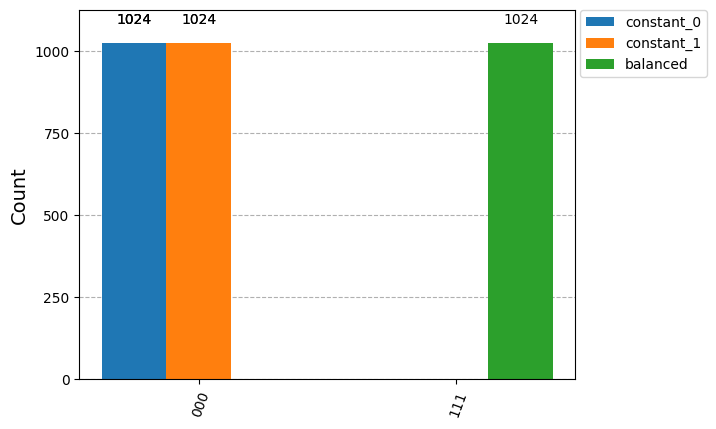

In [41]:
# Deutsch-Jozsa algorithm  - Qiskit example

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Oracle definitions for f:{0,1}^n → {0,1}
# -------------------------------------------------------

def constant_oracle(qc, n, f_value=0):
    """Implements a constant function oracle (f(x)=0 or f(x)=1)."""
    if f_value == 1:
        qc.x(n)  # Flip target qubit (the last one)
    # If f(x)=0, do nothing


def balanced_oracle(qc, n):
    """Implements a balanced oracle: f(x)=sum(x_i) mod 2."""
    for i in range(n):
        qc.cx(i, n)  # CNOT from each input qubit to target


# -------------------------------------------------------
# Deutsch–Jozsa Circuit
# -------------------------------------------------------

def deutsch_jozsa_circuit(oracle_builder, n, **oracle_args):
    qc = QuantumCircuit(n + 1, n)

    # Step 1: Initialize input qubits to |0> and output to |1>
    qc.x(n)        # Set last qubit (target) to |1>
    qc.barrier()

    # Step 2: Apply Hadamard to all qubits
    for i in range(n + 1):
        qc.h(i)
    qc.barrier()

    # Step 3: Apply the oracle
    oracle_builder(qc, n, **oracle_args)
    qc.barrier()

    # Step 4: Apply Hadamard to input qubits again
    for i in range(n):
        qc.h(i)
    qc.barrier()

    # Step 5: Measure only input qubits
    for i in range(n):
        qc.measure(i, i)

    return qc


# -------------------------------------------------------
# Run on simulator
# -------------------------------------------------------

n = 3  # number of input qubits

# Define simulator backend
sim = Aer.get_backend('aer_simulator')

# Define all oracle types to test
oracles = {
    "constant_0": (constant_oracle, {"f_value": 0}),
    "constant_1": (constant_oracle, {"f_value": 1}),
    "balanced"  : (balanced_oracle, {})
}

all_counts = []

# Run Deutsch–Jozsa for each oracle
for name, (builder, args) in oracles.items():
    qc = deutsch_jozsa_circuit(builder, n, **args)
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=1024).result()
    counts = result.get_counts()

    all_counts.append(counts)
    
    print(f"Oracle: {name:10s}  Counts: {counts}")
    display(qc.draw('text'))

plot_histogram(all_counts, legend=list(oracles.keys()))

Dear Students,
Go through Deutsch implementation on a 4-function basis.
Kindly add your simulation code at the above-mentioned cell in the Deutsch-Jozsa implementation.
